In [ ]:
# -*- coding: utf-8 -*-
"""optimized_colab_win_aft.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1bLF9FCWa2aBuVQtUVd35HUbWzLNFut-s
"""

import subprocess
import sys

try:
    import google.colab  # type: ignore  # noqa: F401
except ImportError:
    pass
else:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "catboost", "scipy", "scikit-learn", "pandas", "numpy"],
        check=True,
    )

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, logistic
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from catboost import CatBoostClassifier, CatBoostRegressor, Pool

if "google.colab" not in sys.modules:
    plt.switch_backend("Agg")

SEED = 42
np.random.seed(SEED)

CONFIG = {
    "csv_path": "/content/data/aft_training_20260304_161924_4years.csv",
    "validation_months": 9,
    "landmark_days": [7, 14, 21, 30, 45, 60, 90, 120, 180, 270, 365, 545, 730, 910, 1095],
    "output_dir": "/content/outputs",
    "clf_iterations": 1000,
    "clf_lr": 0.04,
    "clf_depth": 7,
    "clf_l2": 6.0,
    "aft_iterations": 1200,
    "aft_lr": 0.02,
    "aft_depth": 7,
    "aft_l2": 4.0,
    "aft_grid": [("Normal", 0.35), ("Normal", 0.5), ("Normal", 0.75), ("Logistic", 1.25), ("Logistic", 1.5), ("Logistic", 1.75)],
    "eps": 1.0,
}

In [ ]:
def resolve_runtime_paths():
    csv_path = Path(CONFIG["csv_path"])
    if not csv_path.exists():
        local_csv = Path(__file__).resolve().with_name(csv_path.name)
        if local_csv.exists():
            CONFIG["csv_path"] = str(local_csv)

    outdir = Path(CONFIG["output_dir"])
    if str(outdir).startswith("/content/") and "google.colab" not in sys.modules:
        CONFIG["output_dir"] = str(Path(__file__).resolve().parent / "outputs")

resolve_runtime_paths()
outdir = Path(CONFIG["output_dir"])
outdir.mkdir(parents=True, exist_ok=True)

In [ ]:
SEASON_MAP = {
    12: "winter", 1: "winter", 2: "winter",
    3: "spring", 4: "spring", 5: "spring",
    6: "summer", 7: "summer", 8: "summer",
    9: "autumn", 10: "autumn", 11: "autumn",
}

DROP_COLS = {
    "status_category", "pipeline_stage", "gestation_target", "gestation_period",
    "event_observed", "is_censored", "censor_reason", "aft_observed_time",
    "duration_days", "time_open_days", "observation_end_date", "recent_activity_days",
    "id", "monday_id", "item_name", "project_name",
    "date_created", "updated_at", "first_date_designed",
    "date_project_won", "date_project_closed", "first_date_invoiced", "last_date_designed",
    "expected_start_date", "follow_up_date", "date_order_received",
    "probability_percent", "weighted_pipeline", "total_order_value", "sample_weight",
    "t_win", "t_loss", "t_open", "t_end", "created_at", "last_synced_at", "as_of_date",
}

In [ ]:
def build_end_times(df_):
    df_ = df_.copy()
    df_["t_win"] = np.where(df_["status_category"].eq("Won"), df_["gestation_target"], np.nan)
    df_["t_loss"] = np.where(df_["status_category"].eq("Lost"), df_["duration_days"], np.nan)
    df_["t_open"] = np.where(df_["status_category"].eq("Open"), df_["time_open_days"], np.nan)
    df_["t_end"] = np.select(
        [
            df_["status_category"].eq("Won"),
            df_["status_category"].eq("Lost"),
            df_["status_category"].eq("Open"),
        ],
        [df_["t_win"], df_["t_loss"], df_["t_open"]],
        default=np.nan,
    )
    return df_[df_["t_end"].notna() & (df_["t_end"] >= 1)].copy()

In [ ]:
def build_snapshots(base: pd.DataFrame, include_status):
    base = base[base["status_category"].isin(include_status)].copy()
    ldf = pd.DataFrame({"age_days": np.array(CONFIG["landmark_days"], dtype=int)})
    base["__k"] = 1
    ldf["__k"] = 1
    snap = base.merge(ldf, on="__k").drop(columns="__k")
    snap = snap[snap["age_days"] < snap["t_end"]].copy()

    snap["as_of_date"] = snap["date_created"] + pd.to_timedelta(snap["age_days"], unit="D")
    snap["asof_year"] = snap["as_of_date"].dt.year
    snap["asof_quarter"] = snap["as_of_date"].dt.quarter
    snap["asof_month"] = snap["as_of_date"].dt.month
    snap["asof_dayofweek"] = snap["as_of_date"].dt.dayofweek
    snap["asof_weekofyear"] = snap["as_of_date"].dt.isocalendar().week.astype(int)
    snap["asof_season"] = snap["asof_month"].map(SEASON_MAP)

    has_design = snap["first_date_designed"].notna() & (snap["first_date_designed"] <= snap["as_of_date"])
    snap["has_design_by_asof"] = has_design.astype(int)
    snap["days_since_design"] = np.where(
        has_design,
        (snap["as_of_date"] - snap["first_date_designed"]).dt.days,
        np.nan,
    )

    ua = np.minimum(
        snap["updated_at"].values.astype("datetime64[ns]"),
        snap["as_of_date"].values.astype("datetime64[ns]"),
    )
    snap["days_since_updated_asof"] = (
        snap["as_of_date"] - pd.Series(ua, index=snap.index)
    ).dt.days.clip(lower=0)

    snap["log1p_age"] = np.log1p(snap["age_days"])
    snap["value_x_age"] = snap["new_enquiry_value"].fillna(0) * snap["age_days"]
    snap["log_value_x_log_age"] = snap["log_value"].fillna(0) * snap["log1p_age"]
    snap["updated_to_age_ratio"] = snap["days_since_updated_asof"] / (snap["age_days"] + 1)
    snap["design_to_age_ratio"] = snap["days_since_design"] / (snap["age_days"] + 1)
    snap["has_zip"] = snap["zip_code"].notna().astype(int)
    snap["has_sales_rep"] = snap["sales_representative"].notna().astype(int)
    snap["zip_prefix"] = snap["zip_code"].astype(str).str.extract(r"([A-Za-z]+)", expand=False).fillna("Missing")
    snap["account_x_valueband"] = snap["account"].fillna("Missing").astype(str) + "__" + snap["value_band"].fillna("Missing").astype(str)
    snap["rep_x_valueband"] = snap["sales_representative"].fillna("Missing").astype(str) + "__" + snap["value_band"].fillna("Missing").astype(str)
    snap["category_x_product"] = snap["category"].fillna("Missing").astype(str) + "__" + snap["product_type"].fillna("Missing").astype(str)
    snap["type_x_category"] = snap["type"].fillna("Missing").astype(str) + "__" + snap["category"].fillna("Missing").astype(str)

    # Equalize project influence across snapshots
    cnt = snap.groupby("id")["age_days"].transform("count")
    snap["sample_weight"] = 1.0 / cnt
    return snap.reset_index(drop=True)

In [ ]:
def prepare_features(train_snap, val_snap):
    Xtr = train_snap.drop(columns=[c for c in DROP_COLS if c in train_snap.columns], errors="ignore").copy()
    Xva = val_snap.drop(columns=[c for c in DROP_COLS if c in val_snap.columns], errors="ignore").copy()
    common = [c for c in Xtr.columns if c in Xva.columns]
    Xtr = Xtr[common].copy()
    Xva = Xva[common].copy()
    cat_cols = Xtr.select_dtypes(include=["object"]).columns.tolist()
    for c in cat_cols:
        Xtr[c] = Xtr[c].astype("string").fillna("Missing")
        Xva[c] = Xva[c].astype("string").fillna("Missing")
    for c in [c for c in common if c not in cat_cols]:
        Xtr[c] = pd.to_numeric(Xtr[c], errors="coerce")
        Xva[c] = pd.to_numeric(Xva[c], errors="coerce")
    return Xtr, Xva, cat_cols

def add_aft_features(snap: pd.DataFrame) -> pd.DataFrame:
    # Keep AFT-only features separate so the classifier path remains unchanged.
    snap = snap.copy()
    snap["age_sq"] = snap["age_days"] ** 2
    snap["value_per_age"] = snap["new_enquiry_value"].fillna(0) / (snap["age_days"] + 1)
    return snap

def build_aft_labels_remaining(snap: pd.DataFrame, eps: float = 1.0):
    mask_event = snap["status_category"].eq("Won")
    rem_event = (snap.loc[mask_event, "t_win"] - snap.loc[mask_event, "age_days"]).astype(float).clip(lower=eps)
    rem_cens = (snap.loc[~mask_event, "t_open"] - snap.loc[~mask_event, "age_days"]).astype(float).clip(lower=eps)

    lower = np.zeros(len(snap), dtype=float)
    upper = np.zeros(len(snap), dtype=float)
    lower[mask_event.values] = rem_event.values
    upper[mask_event.values] = rem_event.values
    lower[(~mask_event).values] = rem_cens.values
    upper[(~mask_event).values] = -1.0
    return pd.DataFrame({"lower": lower, "upper": upper}, index=snap.index)

In [ ]:
def c_index(times, scores, events):
    times = np.asarray(times, dtype=float)
    scores = np.asarray(scores, dtype=float)
    events = np.asarray(events, dtype=bool)
    order = np.argsort(times)
    times, scores, events = times[order], scores[order], events[order]
    conc = disc = tied = comp = 0
    n = len(times)
    for i in range(n):
        if not events[i]:
            continue
        for j in range(i + 1, n):
            if times[j] == times[i]:
                continue
            comp += 1
            if scores[i] == scores[j]:
                tied += 1
            elif scores[i] < scores[j]:
                conc += 1
            else:
                disc += 1
    return (conc + 0.5 * tied) / comp if comp else np.nan

def aft_eval(model, Xv, yv, snap_v, dist, scale):
    mu = np.asarray(model.predict(Xv), dtype=float)
    z50 = norm.ppf(0.50) if dist == "Normal" else logistic.ppf(0.50)
    p50 = np.exp(np.clip(mu + scale * z50, -10, 10))
    event_mask = snap_v["status_category"].eq("Won").values
    true_rem = (snap_v.loc[event_mask, "t_win"] - snap_v.loc[event_mask, "age_days"]).astype(float).clip(lower=1.0).values
    pred_rem = p50[event_mask]
    mae = float(np.mean(np.abs(true_rem - pred_rem)))
    cidx = float(c_index(yv["lower"].values, mu, event_mask))
    cens_ok = float((p50[~event_mask] > yv.loc[~event_mask, "lower"].values).mean() * 100.0)
    return {"mae_events": mae, "c_index": cidx, "pct_censored_consistent": cens_ok}


In [ ]:
# ------------------------------------------------------------------------------
# DIAGNOSTIC: CHECK FOR FEATURE DOMINANCE / POSSIBLE LEAKAGE
# ------------------------------------------------------------------------------

def check_feature_dominance(
    model,
    X_train,
    model_name="Model",
    suspects=None,
    top_n=20,
    importance_type="PredictionValuesChange",
):
    """
    Extract and plot CatBoost feature importances to identify suspicious dominance.

    Parameters
    ----------
    model : CatBoost model
        Trained CatBoostClassifier or CatBoostRegressor.
    X_train : pd.DataFrame
        Training feature matrix used for the model.
    model_name : str
        Label used in printed output and chart titles.
    suspects : list[str] or None
        Specific features to inspect for leakage risk.
    top_n : int
        Number of top features to print/plot.
    importance_type : str
        CatBoost importance type. 'PredictionValuesChange' is the most convenient
        default for both classifier and regressor diagnostics.
    """
    if model is None:
        print(f"\n[{model_name}] No model found. Skipping feature dominance check.")
        return None

    if X_train is None or len(X_train.columns) == 0:
        print(f"\n[{model_name}] X_train is empty or missing. Skipping feature dominance check.")
        return None

    if suspects is None:
        suspects = [
            # original/raw candidates
            "days_since_updated",
            "recent_activity_days",
            "probability_percent",
            # current engineered / as-of candidates
            "days_since_updated_asof",
            "updated_to_age_ratio",
            "days_since_design",
            "design_to_age_ratio",
            "age_days",
            "log1p_age",
        ]

    # Get feature importance
    importance = model.get_feature_importance(type=importance_type)

    fi_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False).reset_index(drop=True)

    print("\n" + "=" * 80)
    print(f"TOP {top_n} FEATURES - {model_name}")
    print("=" * 80)
    print(fi_df.head(top_n).to_string(index=True))

    # Dominance checks
    top_feature = fi_df.iloc[0]
    print("\n--- Dominance Summary ---")
    print(f"Top feature: {top_feature['Feature']} | Importance: {top_feature['Importance']:.4f}")

    if top_feature["Importance"] > 50:
        print("WARNING: A single feature contributes >50% importance. Strong leakage suspicion.")
    elif top_feature["Importance"] > 35:
        print("CAUTION: A single feature is highly dominant. Inspect carefully.")
    else:
        print("No single feature appears overwhelmingly dominant.")

    fi_df["CumulativeImportance"] = fi_df["Importance"].cumsum()
    n80 = (fi_df["CumulativeImportance"] <= 80).sum()
    print(f"Features needed to reach ~80% importance: {max(n80, 1)}")

    # Suspect feature ranking
    print("\n--- Suspect Features Rank ---")
    for suspect in suspects:
        match = fi_df[fi_df["Feature"] == suspect]
        if not match.empty:
            row = match.iloc[0]
            rank = int(match.index[0]) + 1
            print(f"'{suspect}': Rank #{rank} | Score: {row['Importance']:.4f}")
        else:
            print(f"'{suspect}': Not found in model features.")

    # Plot top-N
    top_plot = fi_df.head(top_n).sort_values("Importance", ascending=True)

    plt.figure(figsize=(10, max(6, top_n * 0.35)))
    plt.barh(top_plot["Feature"], top_plot["Importance"])
    plt.title(f"CatBoost Feature Importance ({model_name}) - Top {top_n}")
    plt.xlabel(f"Importance Score ({importance_type})")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    return fi_df


In [ ]:
def main():
    df = pd.read_csv(CONFIG["csv_path"])

    for c in [
        "date_created", "updated_at", "first_date_designed",
        "date_project_won", "date_project_closed", "first_date_invoiced",
        "last_date_designed", "observation_end_date", "created_at", "last_synced_at",
        "expected_start_date", "follow_up_date", "date_order_received"
    ]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

    for c in [
        "gestation_target", "duration_days", "time_open_days",
        "new_enquiry_value", "log_value", "project_value",
        "probability_percent", "weighted_pipeline", "total_order_value",
        "days_since_created", "days_since_updated", "recent_activity_days",
        "aft_observed_time"
    ]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df = build_end_times(df)
    cutoff = df["date_created"].max() - pd.DateOffset(months=CONFIG["validation_months"])
    train = df[df["date_created"] <= cutoff].copy()
    val = df[df["date_created"] > cutoff].copy()

    # ---------- Classifier ----------
    snap_train_clf = build_snapshots(train, ("Won", "Lost"))
    snap_val_clf = build_snapshots(val, ("Won", "Lost"))
    X_train_clf, X_val_clf, cat_clf = prepare_features(snap_train_clf, snap_val_clf)
    y_train_clf = snap_train_clf["status_category"].eq("Won").astype(int).values
    y_val_clf = snap_val_clf["status_category"].eq("Won").astype(int).values
    w_train_clf = snap_train_clf["sample_weight"].values

    train_pool_clf = Pool(X_train_clf, label=y_train_clf, cat_features=cat_clf, weight=w_train_clf)
    val_pool_clf = Pool(X_val_clf, label=y_val_clf, cat_features=cat_clf)

    clf = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=CONFIG["clf_iterations"],
        learning_rate=CONFIG["clf_lr"],
        depth=CONFIG["clf_depth"],
        l2_leaf_reg=CONFIG["clf_l2"],
        random_seed=SEED,
        od_type="Iter",
        od_wait=70,
        bootstrap_type="Bernoulli",
        subsample=0.85,
        auto_class_weights="Balanced",
        allow_writing_files=False,
        verbose=100,
    )
    clf.fit(train_pool_clf, eval_set=val_pool_clf, use_best_model=True)
    p_val = clf.predict_proba(X_val_clf)[:, 1]

    fi_clf = check_feature_dominance(
        model=clf,
        X_train=X_train_clf,
        model_name="Win Classifier",
        suspects=[
            "days_since_updated",
            "recent_activity_days",
            "probability_percent",
            "days_since_updated_asof",
            "updated_to_age_ratio",
            "days_since_design",
            "design_to_age_ratio",
            "age_days",
            "log1p_age",
        ],
        top_n=20,
    )

    print("\n--- Win Classifier Metrics (Val) ---")
    print(f"AUC:    {roc_auc_score(y_val_clf, p_val):.4f}")
    print(f"PR-AUC: {average_precision_score(y_val_clf, p_val):.4f}")
    print(f"Brier:  {brier_score_loss(y_val_clf, p_val):.4f}")

    # ---------- AFT ----------
    snap_train_aft = add_aft_features(build_snapshots(train, ("Won", "Open")))
    snap_val_aft = add_aft_features(build_snapshots(val, ("Won", "Open")))
    X_train_aft, X_val_aft, cat_aft = prepare_features(snap_train_aft, snap_val_aft)
    y_train_aft = build_aft_labels_remaining(snap_train_aft, CONFIG["eps"])
    y_val_aft = build_aft_labels_remaining(snap_val_aft, CONFIG["eps"])
    w_train_aft = snap_train_aft["sample_weight"].values

    train_pool_aft = Pool(X_train_aft, label=y_train_aft, cat_features=cat_aft, weight=w_train_aft)
    val_pool_aft = Pool(X_val_aft, label=y_val_aft, cat_features=cat_aft)

    best = None
    best_model = None
    for dist, scale in CONFIG["aft_grid"]:
        model = CatBoostRegressor(
            loss_function=f"SurvivalAft:dist={dist};scale={scale}",
            eval_metric="SurvivalAft",
            iterations=CONFIG["aft_iterations"],
            learning_rate=CONFIG["aft_lr"],
            depth=CONFIG["aft_depth"],
            l2_leaf_reg=CONFIG["aft_l2"],
            random_seed=SEED,
            od_type="Iter",
            od_wait=60,
            bootstrap_type="Bernoulli",
            subsample=0.85,
            allow_writing_files=False,
            verbose=False,
        )
        model.fit(train_pool_aft, eval_set=val_pool_aft, use_best_model=True)
        ev = aft_eval(model, X_val_aft, y_val_aft, snap_val_aft, dist, scale)
        row = {"dist": dist, "scale": scale, "best_iteration": int(model.get_best_iteration() or 0), **ev}
        print("[AFT sweep]", row)

        if (best is None) or (
            row["mae_events"] < best["mae_events"] and row["c_index"] >= best["c_index"] - 0.02
        ):
            best = row
            best_model = model

    print("\n--- Best AFT (remaining) ---")
    print(best)

    fi_aft = None
    if best_model is not None:
        fi_aft = check_feature_dominance(
            model=best_model,
            X_train=X_train_aft,
            model_name="AFT Remaining Time",
            suspects=[
                "days_since_updated",
                "recent_activity_days",
                "probability_percent",
                "days_since_updated_asof",
                "updated_to_age_ratio",
                "days_since_design",
                "design_to_age_ratio",
                "age_days",
                "log1p_age",
            ],
            top_n=20,
        )

    clf.save_model(str(outdir / "win_classifier_optimized.cbm"))
    if best_model is not None:
        best_model.save_model(str(outdir / "aft_remaining_optimized.cbm"))

    if fi_clf is not None:
        fi_clf.to_csv(outdir / "feature_importance_classifier.csv", index=False)

    if fi_aft is not None:
        fi_aft.to_csv(outdir / "feature_importance_aft.csv", index=False)

    with open(outdir / "training_meta_optimized.json", "w") as f:
        json.dump(
            {
                "classifier": {
                    "auc": float(roc_auc_score(y_val_clf, p_val)),
                    "pr_auc": float(average_precision_score(y_val_clf, p_val)),
                    "brier": float(brier_score_loss(y_val_clf, p_val)),
                },
                "aft": best,
            },
            f,
            indent=2,
        )

    print("\nSaved optimized artifacts to:", outdir)


0:	test: 0.7886288	best: 0.7886288 (0)	total: 157ms	remaining: 2m 36s
Stopped by overfitting detector  (70 iterations wait)

bestTest = 0.820550801
bestIteration = 17

Shrink model to first 18 iterations.

TOP 20 FEATURES - Win Classifier
                 Feature  Importance
0               feedback   30.814296
1             zip_prefix   15.041271
2                account   12.216162
3    account_x_valueband   10.797337
4     category_x_product    7.117967
5              log1p_age    4.498224
6    log_value_x_log_age    3.807986
7            value_x_age    3.530578
8   sales_representative    3.128229
9     lost_to_who_or_why    2.713821
10              age_days    1.677367
11       rep_x_valueband    1.292644
12             log_value    0.982573
13          created_year    0.642730
14    days_since_created    0.571718
15       type_x_category    0.447432
16              category    0.274939
17       asof_weekofyear    0.225741
18     new_enquiry_value    0.218986
19              zip_c

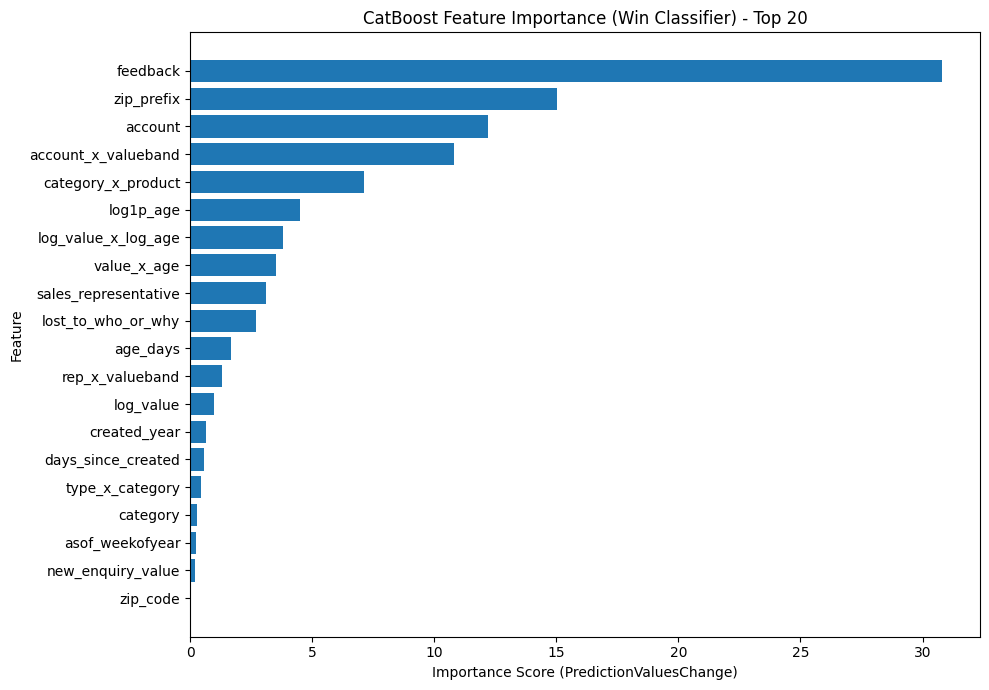


--- Win Classifier Metrics (Val) ---
AUC:    0.8206
PR-AUC: 0.9030
Brier:  0.1481
[AFT sweep] {'dist': 'Normal', 'scale': 0.35, 'best_iteration': 216, 'mae_events': 83.87576340328172, 'c_index': 0.6764755714843941, 'pct_censored_consistent': 88.88090533500987}
[AFT sweep] {'dist': 'Normal', 'scale': 0.5, 'best_iteration': 144, 'mae_events': 69.21430324860022, 'c_index': 0.6696827071020368, 'pct_censored_consistent': 81.31848392311838}
[AFT sweep] {'dist': 'Normal', 'scale': 0.75, 'best_iteration': 141, 'mae_events': 82.12363265722378, 'c_index': 0.6761996745713867, 'pct_censored_consistent': 84.9290461649003}
[AFT sweep] {'dist': 'Logistic', 'scale': 1.25, 'best_iteration': 51, 'mae_events': 120.17882628291439, 'c_index': 0.6842411346651688, 'pct_censored_consistent': 88.57553439913778}
[AFT sweep] {'dist': 'Logistic', 'scale': 1.5, 'best_iteration': 47, 'mae_events': 117.92077979207608, 'c_index': 0.7130950672837396, 'pct_censored_consistent': 90.1562780671816}
[AFT sweep] {'dist': '

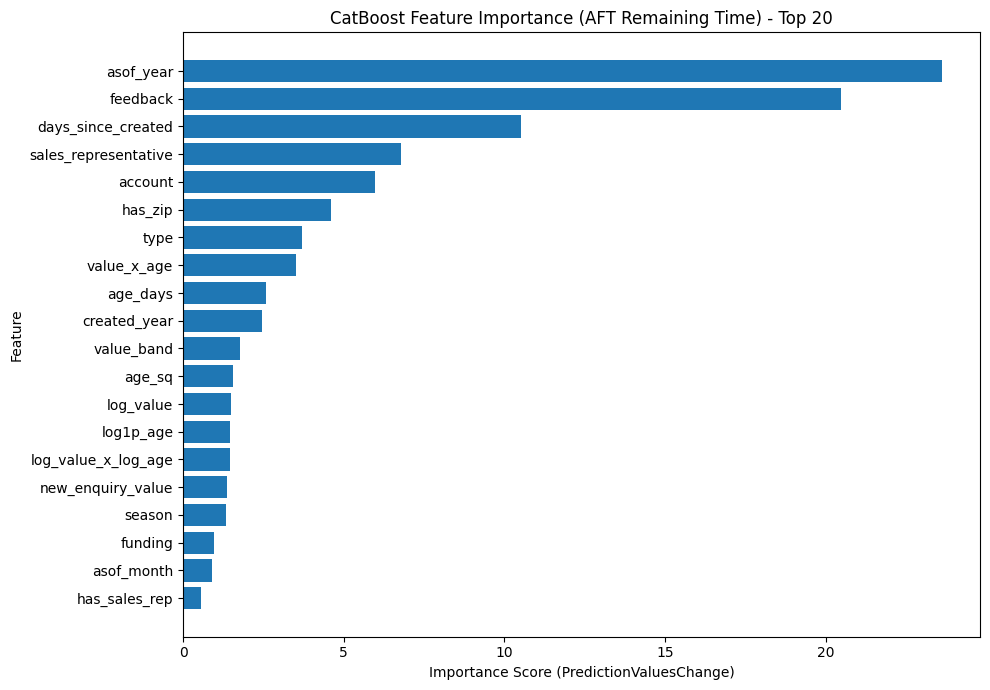


Saved optimized artifacts to: /content/outputs


In [ ]:
if __name__ == "__main__":
    main()